<a href="https://colab.research.google.com/github/Janmeshree/DAV-PRACS/blob/main/DAV_SENTIMENT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from textblob import TextBlob

In [13]:
nltk.download('punkt')
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

data = pd.read_csv(url)

data = data[['label', 'tweet']]
data.rename(columns={'tweet': 'review'}, inplace=True)

data.head()

,label,review
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [15]:
def clean(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    return text

data['clean_text'] = data['review'].apply(clean)

In [16]:
data['tokens'] = data['clean_text'].apply(word_tokenize)

In [17]:
stop_words = set(stopwords.words('english'))

data['tokens'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [18]:
stemmer = PorterStemmer()

data['stemmed'] = data['tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [19]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [20]:
data['sentiment'] = data['review'].apply(get_sentiment)

data[['review', 'sentiment']].head()

,review,sentiment
0,@user when a father is dysfunctional and is s...,Negative
1,@user @user thanks for #lyft credit i can't us...,Positive
2,bihday your majesty,Neutral
3,#model i love u take with u all the time in ...,Positive
4,factsguide: society now #motivation,Neutral


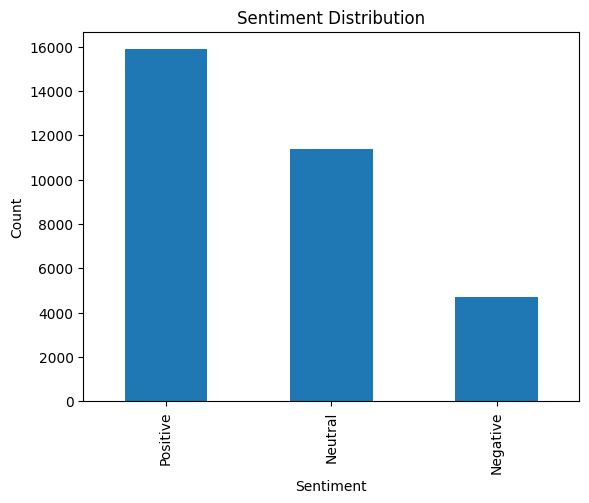

In [21]:
data['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()